# Case Study: Barbenheimer — When Two Films Broke the Box Office Together (2023)

**Last Updated**: April 2026  
**Data Source**: DuckDB Database (`data/db/movies.duckdb`)  
**Status**: ✅ Complete

## Overview

On July 21, 2023, something happened that Hollywood's scheduling playbook said *shouldn't* work: two radically different films opened on the same day — and both became massive hits. *Barbie*, Greta Gerwig's neon-pink, self-aware comedy about a plastic doll, and *Oppenheimer*, Christopher Nolan's three-hour, R-rated epic about the father of the atomic bomb, collided head-on. The internet did what the internet does and mashed them together: **Barbenheimer** was born.

Instead of cannibalizing each other, the two films fed off one another's hype. Couples negotiated double features. Friend groups split and then swapped. Memes turned a scheduling coincidence into *the* cultural moment of 2023. Together they grossed nearly **$2.4 billion** worldwide on a combined budget of just **$245 million** — a nearly 10x return that most franchise tentpoles would kill for.

This notebook dissects the Barbenheimer phenomenon:

1. **💥 The Barbenheimer Phenomenon** — the numbers behind the meme
2. **🥊 Head-to-Head: Barbie vs. Oppenheimer** — budget, revenue, ratings, and vibes
3. **🎬 Christopher Nolan's Career Arc** — how Oppenheimer became his most efficient blockbuster (and a comeback from Tenet)
4. **📊 2023 Box Office Context** — a year of extremes, dominated by Barbenheimer
5. **🤝 The Symbiosis Effect** — why competition became collaboration
6. **🎥 The Directors** — Nolan's mastery meets Gerwig's breakout

**Fair warning**: this is not a neutral analysis. I have strong opinions about both films — one made me want to defend cinema as an art form, the other made me want to argue with the screen. The data is impartial. The commentary is not. You'll see where I stand soon enough.

## Setup

In [1]:
import os
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# Dark mode styling (configures matplotlib, Plotly template + renderer)
from ayne.utils.plotting import configure_dark_mode
configure_dark_mode()

# Project root setup
from pyprojroot import here
os.chdir(here())

# Project utilities
from ayne.utils.query_utils import execute_custom_query, get_db_client

In [2]:
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"${x:,.0f}" if abs(x) > 1000 else f"{x:.2f}")

# Color palette (optimized for dark backgrounds)
COLORS = {
    "barbie": "#E91E8C",       # Hot pink
    "oppenheimer": "#FF9500",  # Orange (nuclear/fire aesthetic)
    "nolan": "#5B7C99",        # Steel blue
    "nolan_accent": "#5DADE2", # Sky blue
    "combined": "#B565E0",     # Bright purple
    "comparison": "#2A9D8F",   # Teal
    "neutral": "#9E9E9E",      # Light gray
    "profit": "#4CAF50",       # Bright green
    "loss": "#D62828",         # Red
    "gerwig": "#E74C3C",       # Red-coral
}

def fmt_millions(val):
    """Format a number as $XM or $X.XB."""
    if abs(val) >= 1e9:
        return f"${val / 1e9:.1f}B"
    return f"${val / 1e6:.0f}M"

---

## 1. 💥 The Barbenheimer Phenomenon

Two films. Same release date. Completely opposite vibes. A 114-minute PG-13 comedy drenched in hot pink, and a 181-minute R-rated historical drama in muted grays. By every rule of Hollywood scheduling, this should have been a cannibalization disaster — one film stealing the other's opening weekend. Instead, it became the biggest cultural event of 2023 and turned "I'm doing the double feature" into a badge of honor.

Let's load the data and see what all the fuss was about.

In [3]:
# Load Barbie and Oppenheimer from the database
barbenheimer = execute_custom_query("""
    SELECT
        m.title,
        t.release_date,
        t.budget,
        t.revenue,
        t.runtime,
        t.vote_average AS tmdb_rating,
        t.vote_count AS tmdb_votes,
        t.genres,
        o.imdb_rating,
        o.imdb_votes,
        o.rotten_tomatoes_rating AS rt_score,
        o.metascore,
        o.director,
        o.actors,
        o.rated,
        o.awards,
        o.box_office AS us_box_office,
        o.genre AS omdb_genre
    FROM movies m
    JOIN tmdb_movies t ON m.tmdb_id = t.tmdb_id
    LEFT JOIN omdb_movies o ON m.imdb_id = o.imdb_id
    WHERE m.title IN ('Barbie', 'Oppenheimer')
    ORDER BY t.release_date
""")

barbenheimer["release_year"] = pd.to_datetime(barbenheimer["release_date"]).dt.year
barbenheimer["roi"] = (barbenheimer["revenue"] / barbenheimer["budget"]).round(2)
barbenheimer["profit"] = barbenheimer["revenue"] - barbenheimer["budget"]
barbenheimer["intl_box_office"] = barbenheimer["revenue"] - barbenheimer["us_box_office"]
barbenheimer["domestic_pct"] = (barbenheimer["us_box_office"] / barbenheimer["revenue"] * 100).round(1)

barbie = barbenheimer[barbenheimer["title"] == "Barbie"].iloc[0]
oppenheimer = barbenheimer[barbenheimer["title"] == "Oppenheimer"].iloc[0]

# Combined stats
combined_budget = barbie["budget"] + oppenheimer["budget"]
combined_revenue = barbie["revenue"] + oppenheimer["revenue"]
combined_roi = round(combined_revenue / combined_budget, 2)

print(f"Release date: {barbie['release_date'].strftime('%B %d, %Y')}")
print(f"Combined budget:  {fmt_millions(combined_budget)}")
print(f"Combined revenue: {fmt_millions(combined_revenue)}")
print(f"Combined ROI:     {combined_roi}x")
print(f"\nBarbie:       {fmt_millions(barbie['revenue'])} on {fmt_millions(barbie['budget'])} ({barbie['roi']}x)")
print(f"Oppenheimer:  {fmt_millions(oppenheimer['revenue'])} on {fmt_millions(oppenheimer['budget'])} ({oppenheimer['roi']}x)")

Release date: July 19, 2023
Combined budget:  $245M
Combined revenue: $2.4B
Combined ROI:     9.79x

Barbie:       $1.4B on $145M (9.98x)
Oppenheimer:  $952M on $100M (9.52x)


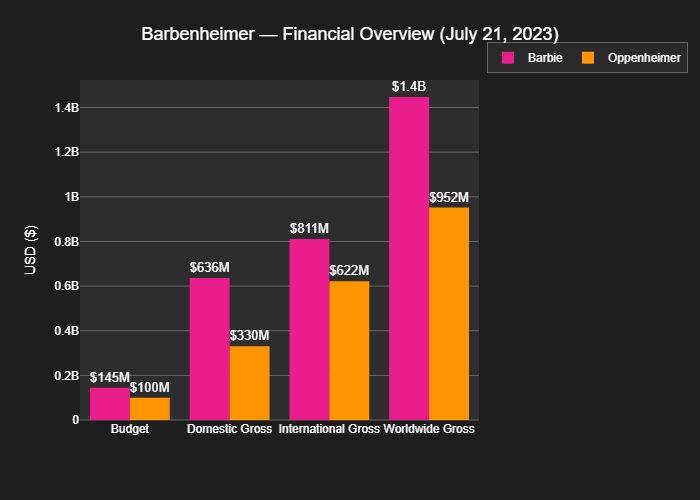

In [4]:
# The Barbenheimer overview — side-by-side financial comparison
fig = go.Figure()

categories = ["Budget", "Domestic Gross", "International Gross", "Worldwide Gross"]

barbie_vals = [
    barbie["budget"], barbie["us_box_office"],
    barbie["intl_box_office"], barbie["revenue"],
]
opp_vals = [
    oppenheimer["budget"], oppenheimer["us_box_office"],
    oppenheimer["intl_box_office"], oppenheimer["revenue"],
]

fig.add_trace(go.Bar(
    x=categories, y=barbie_vals, name="Barbie",
    marker_color=COLORS["barbie"],
    text=[fmt_millions(v) for v in barbie_vals], textposition="outside",
))
fig.add_trace(go.Bar(
    x=categories, y=opp_vals, name="Oppenheimer",
    marker_color=COLORS["oppenheimer"],
    text=[fmt_millions(v) for v in opp_vals], textposition="outside",
))

fig.update_layout(
    title="Barbenheimer — Financial Overview (July 21, 2023)",
    barmode="group",
    yaxis_title="USD ($)", height=500,
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
)
fig.show()

### The Numbers Behind the Phenomenon

Let those numbers sink in:

- **Barbie** earned **$1.45B** worldwide on a $145M budget — a **10.0x** return. It became the highest-grossing film of 2023, the highest-grossing film ever directed by a woman, and the first billion-dollar movie adapted from a toy line. Commercially, it's bulletproof. Narratively... we'll get to that.
- **Oppenheimer** earned **$952M** worldwide on just a $100M budget — a **9.5x** return. For a *three-hour, R-rated historical drama about nuclear physics*, this is borderline absurd. The fact that a film where half the dialogue is about quantum mechanics and government security clearances nearly hit a billion dollars tells you everything about what Nolan's name means on a marquee.
- **Combined Barbenheimer haul**: **$2.4B** on $245M — a combined **9.8x** ROI. Most franchise tentpoles with triple the budget would kill for those numbers.
- Barbie dominated domestically (44% US), while Oppenheimer traveled further internationally (65% overseas), proving their appeal was truly global.

The conventional wisdom says two big releases on the same weekend **split** the audience and hurt both films. Barbenheimer didn't just disprove that — it set the whole theory on fire.

---

## 2. 🥊 Head-to-Head: Barbie vs. Oppenheimer

Pink vs. doom. Plastic dreamhouse vs. nuclear apocalypse. Margot Robbie rollerblading vs. Cillian Murphy staring into the void. Let's compare these two unlikely companions across every dimension — and if you can't already tell which one I think is the better *film* (hint: it's the one about physics and guilt, not the one about a doll discovering she has flat feet), the data will make it obvious.

In [5]:
# Detailed comparison table
def safe_pct(val):
    return f"{int(val)}%" if pd.notna(val) else "N/A"

comparison = pd.DataFrame({
    "Metric": [
        "Director", "Lead Cast", "Genre", "Age Rating", "Runtime (min)",
        "Budget", "US Domestic Gross", "International Gross", "Worldwide Gross",
        "Domestic Share", "ROI Multiple",
        "TMDB Rating", "IMDb Rating", "Rotten Tomatoes", "Metascore",
        "TMDB Vote Count", "IMDb Vote Count",
        "Awards",
    ],
    "Barbie": [
        barbie["director"], barbie["actors"],
        barbie["omdb_genre"], barbie["rated"], int(barbie["runtime"]),
        fmt_millions(barbie["budget"]),
        fmt_millions(barbie["us_box_office"]),
        fmt_millions(barbie["intl_box_office"]),
        fmt_millions(barbie["revenue"]),
        f"{barbie['domestic_pct']:.1f}%",
        f"{barbie['roi']:.2f}x",
        barbie["tmdb_rating"], barbie["imdb_rating"],
        safe_pct(barbie["rt_score"]), int(barbie["metascore"]),
        f"{int(barbie['tmdb_votes']):,}", f"{int(barbie['imdb_votes']):,}",
        barbie["awards"],
    ],
    "Oppenheimer": [
        oppenheimer["director"], oppenheimer["actors"],
        oppenheimer["omdb_genre"], oppenheimer["rated"], int(oppenheimer["runtime"]),
        fmt_millions(oppenheimer["budget"]),
        fmt_millions(oppenheimer["us_box_office"]),
        fmt_millions(oppenheimer["intl_box_office"]),
        fmt_millions(oppenheimer["revenue"]),
        f"{oppenheimer['domestic_pct']:.1f}%",
        f"{oppenheimer['roi']:.2f}x",
        oppenheimer["tmdb_rating"], oppenheimer["imdb_rating"],
        safe_pct(oppenheimer["rt_score"]), int(oppenheimer["metascore"]),
        f"{int(oppenheimer['tmdb_votes']):,}", f"{int(oppenheimer['imdb_votes']):,}",
        oppenheimer["awards"],
    ],
})

comparison.style.set_properties(**{"text-align": "left"}).set_table_styles(
    [{"selector": "th", "props": [("text-align", "left")]}]
)

,Metric,Barbie,Oppenheimer
0,Director,Greta Gerwig,Christopher Nolan
1,Lead Cast,"Margot Robbie, Issa Rae, Kate McKinnon","Cillian Murphy, Emily Blunt, Robert Downey Jr."
2,Genre,"Adventure, Comedy, Fantasy","Biography, Drama, History"
3,Age Rating,PG-13,R
4,Runtime (min),114,181
5,Budget,$145M,$100M
6,US Domestic Gross,$636M,$330M
7,International Gross,$811M,$622M
8,Worldwide Gross,$1.4B,$952M
9,Domestic Share,44.0%,34.7%


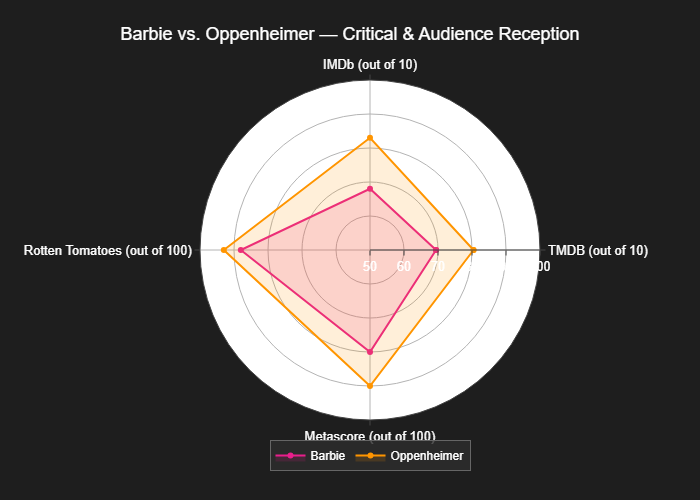

In [6]:
# Ratings radar chart — comparing audience & critical reception
rating_categories = ["TMDB\n(out of 10)", "IMDb\n(out of 10)", "Rotten Tomatoes\n(out of 100)", "Metascore\n(out of 100)"]

# Normalize everything to 0–100 scale for the radar
barbie_ratings = [
    barbie["tmdb_rating"] * 10,
    barbie["imdb_rating"] * 10,
    barbie["rt_score"],
    barbie["metascore"],
]
opp_ratings = [
    oppenheimer["tmdb_rating"] * 10,
    oppenheimer["imdb_rating"] * 10,
    oppenheimer["rt_score"],
    oppenheimer["metascore"],
]

fig = go.Figure()
fig.add_trace(go.Scatterpolar(
    r=barbie_ratings + [barbie_ratings[0]],
    theta=rating_categories + [rating_categories[0]],
    fill="toself", name="Barbie",
    line_color=COLORS["barbie"], fillcolor="rgba(233, 30, 140, 0.15)",
))
fig.add_trace(go.Scatterpolar(
    r=opp_ratings + [opp_ratings[0]],
    theta=rating_categories + [rating_categories[0]],
    fill="toself", name="Oppenheimer",
    line_color=COLORS["oppenheimer"], fillcolor="rgba(255, 149, 0, 0.15)",
))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[50, 100])),
    title="Barbie vs. Oppenheimer — Critical & Audience Reception",
    height=500,
    legend=dict(orientation="h", yanchor="bottom", y=-0.15, xanchor="center", x=0.5),
)
fig.show()

### Two Completely Different Films, Both Winners

| Dimension | 🩷 Barbie | 🖤 Oppenheimer |
|-----------|--------|-------------|
| **Core audience** | Women 18–40, families | Men 25–55, cinephiles |
| **Tone** | Playful, satirical, "I'm just Ken" | Somber, cerebral, "Now I am become Death" |
| **Runtime** | 114 min (breezy popcorn vibes) | 181 min (bring a cushion) |
| **Rating** | PG-13 (broad appeal) | R (limited but dedicated audience) |
| **Budget efficiency** | $145M → $1.45B (10.0x) | $100M → $952M (9.5x) |

Key observations:
- **Oppenheimer punches absurdly above its weight**: A 3-hour R-rated biography earning nearly $1B is almost unheard of. For context, only a handful of R-rated films have *ever* crossed $500M worldwide. Nolan made a movie about *nuclear physics committee meetings* and still nearly hit a billion. That's not just a good result — that's a flex.
- **Barbie dominated domestically** (44% US share vs. 35% for Oppenheimer), reflecting the toy brand's deeper cultural footprint in American pop culture. International audiences were slightly less enamored — make of that what you will.
- **Oppenheimer won the critics decisively** (93% RT, 90 Metascore, 8.3 IMDb) while Barbie was well-received but more polarizing (88% RT, 80 Metascore, 6.8 IMDb). That 1.5-point IMDb gap is significant — it reflects the audience divide that the RT percentage doesn't capture. A lot of people walked out of Barbie going "...wait, what was the point of that ending?"
- **Both won Oscars**: Oppenheimer swept with 7 wins (including Best Picture, Director, Actor); Barbie won 1 (Best Original Song) with 8 nominations. And yes, that sole win was for Ryan Gosling's song — the one performed by the character the film was openly mocking. Hollywood has a sense of humor.

> 💡 The Barbenheimer effect turned moviegoing into a **social event**. Couples did double features — one partner's pick first, then the other's. The contrast between the two *was* the entertainment. You could argue that neither film would have done quite as well without the other — a rare case of schedule competition creating a rising tide that lifted both boats. Though I'd argue one of those boats had much better structural integrity than the other.

### Author's Take: Why Barbie Doesn't Sit Right

The financial analysis is clear — Barbie was a monster hit, and objectively one of the most successful films of the decade. But watching the actual *film*? That's where things get complicated. Because for all its commercial brilliance, Barbie is a movie that seems to trip over its own message at nearly every turn.

#### The Feminist Lens — And Its Contradictions

Barbie is, unmistakably, a modern feminist's view of the world. Men are bro-ing out and having it easy. Women are constantly judged on their appearance and treated harshly — especially by men. Fair enough as a premise. But the execution doesn't hold up under scrutiny.

Barbie World is presented as a **utopia** — and in this utopia, all the important jobs are held by women. Kens are decorative accessories with no purpose. The movie wants you to see this as aspirational. But strip away the pink coating and it's just... the patriarchy in reverse? A world where one gender is systematically excluded from meaningful participation isn't a utopia — it's the same problem with a different coat of paint.

The film seems to want women to be simultaneously **strong, smart, and all-capable** *and also* **victims who need to be pitied and helped**. You can't have both. If the Barbies are as powerful and competent as the movie tells us they are, then the entire second-act collapse makes no sense — and if they're actually vulnerable, then the first act's utopia was a lie. The movie never resolves this tension. It just vibes past it.

#### The Plot — Let's Not Think Too Hard About It

Speaking of that second-act collapse: Ken discovers patriarchy in the real world, returns to Barbie World, and *immediately* takes over. The supposedly strong, smart, powerful Barbies — who run their entire civilization — can do... nothing? They just fold? What happened to all that girl power from twenty minutes ago?

And here's the part that really doesn't work: during Ken's takeover, **everyone is visibly happy**. The Kens are having a blast. The Barbies seem relaxed. If the movie wanted to show Ken's world as oppressive or wrong, it didn't do a great job — because the vibe is "beach party" not "dystopia." Then Barbie shows back up and forcibly restores the old order, despite everyone seemingly enjoying themselves. One person enforces their will on an entire society that appeared content? That's not liberation — that's just authoritarian but it's all in pink so it's cute instead of oppressive I guess...

The ending settles back into women ruling and Kens getting "a little bit of power, as a treat." The thesis, apparently, is that the correct world order is one where women are in charge and men are tolerated. Hard to read that as anything other than contempt dressed up as comedy.

#### Ryan Gosling and the Great Irony

Here's the wonderful irony that the movie accidentally created: Ken is clearly *the butt of every joke*. He exists to be mocked, sidelined, and patronized. And yet Ryan Gosling absolutely **steals the entire movie** with sheer charisma, comic timing, and commitment to the bit. "I'm Just Ken" became the film's most iconic moment — and Gosling earned an Oscar nomination (and won for the song) playing a character the film was openly contemptuous of.

The man who the movie repeatedly tells you *doesn't matter* ended up being the reason most people left the theater smiling. If that's not a case of a film undermining its own thesis, I don't know what is.

#### Motherhood Gets the Cold Shoulder

There's a subplot involving a mother and her daughter that early on seemed like it might explore the value of motherhood — one of the most profound experiences many women have. Instead, the film swerves away from that entirely, reinforcing the sense that this is a very specific modern feminist lens that doesn't have much time for traditional feminine experiences unless they're being subverted.

The opening scene hammers this home with all the subtlety of a sledgehammer: little girls discover Barbie and immediately **smash their baby dolls** to pieces. It's played as liberation —  "girls don't just have to play mommy!" — but it reads more as an attack on the concept of motherhood itself. Heavy-handed doesn't begin to cover it.

And then there's the fundamental Barbie paradox: the doll has always been a symbol of **unattainable physical beauty**. So the feminist message is... that women should strive to look like a plastic doll with impossible proportions? Barbie-as-feminist-icon is a contradiction that the film never addresses. It just hopes the pink production design is distracting enough that you won't notice.

#### The Gynecologist Ending

The film ends with Barbie becoming human and excitedly going to her first gynecologist appointment. That's the punchline. That's what the movie decided was the most important statement about what it means to be a real woman. After two hours of big themes about identity, purpose, and gender politics — the conclusion is a medical appointment joke. It's an odd note to end on, to put it mildly.

> 🎭 **To be clear**: None of this diminishes Barbie's commercial achievement — a $1.45B gross is a $1.45B gross, and the marketing was masterful. Greta Gerwig made a visually stunning film that started a global conversation. But "started a conversation" and "made a coherent argument" are two very different things. The numbers say smash hit. The script says... it's complicated.

---

## 3. 🎬 Christopher Nolan — A Career in Numbers

Oppenheimer didn't just ride the Barbenheimer wave — it also marks one of the great comeback arcs in modern Hollywood. After the COVID-hobbled *Tenet* (2020) became his first genuine underperformer, and after his very public divorce from Warner Bros. over simultaneous streaming releases, Nolan decamped to Universal with something to prove.

He proved it. Oppenheimer was his most commercially efficient blockbuster — and the film that *finally* won him the Best Director Oscar after a career of being "the best director who's never won."

Let's trace his full filmography.

In [7]:
# Load Nolan's full filmography
nolan = execute_custom_query("""
    SELECT
        t.title,
        t.release_date,
        t.budget,
        t.revenue,
        t.runtime,
        t.vote_average AS tmdb_rating,
        t.vote_count AS tmdb_votes,
        o.imdb_rating,
        o.rotten_tomatoes_rating AS rt_score,
        o.metascore,
        o.director,
        o.rated,
        o.awards
    FROM tmdb_movies t
    LEFT JOIN movies m ON t.tmdb_id = m.tmdb_id
    LEFT JOIN omdb_movies o ON m.imdb_id = o.imdb_id
    WHERE t.title IN (
        'Following', 'Memento', 'Insomnia', 'Batman Begins',
        'The Prestige', 'The Dark Knight', 'Inception',
        'The Dark Knight Rises', 'Interstellar', 'Dunkirk',
        'Tenet', 'Oppenheimer'
    )
    AND t.budget > 0 AND t.revenue > 0
    ORDER BY t.release_date
""")

# Supplement missing OMDB data with well-known public data
nolan_known = {
    "Following": {"imdb_rating": 7.5, "rt_score": 80, "metascore": 61, "rated": "R"},
    "Memento": {"imdb_rating": 8.4, "rt_score": 93, "metascore": 80, "rated": "R"},
    "Insomnia": {"imdb_rating": 7.2, "rt_score": 92, "metascore": 78, "rated": "R"},
    "Batman Begins": {"imdb_rating": 8.2, "rt_score": 84, "metascore": 70, "rated": "PG-13"},
    "The Prestige": {"imdb_rating": 8.5, "rt_score": 76, "metascore": 66, "rated": "PG-13"},
    "The Dark Knight": {"imdb_rating": 9.0, "rt_score": 94, "metascore": 84, "rated": "PG-13"},
    "Inception": {"imdb_rating": 8.8, "rt_score": 87, "metascore": 74, "rated": "PG-13"},
}

for title, data in nolan_known.items():
    mask = nolan["title"] == title
    for col, val in data.items():
        if mask.any() and (pd.isna(nolan.loc[mask, col].values[0]) or nolan.loc[mask, col].values[0] is None):
            nolan.loc[mask, col] = val

nolan["release_year"] = pd.to_datetime(nolan["release_date"]).dt.year
nolan["roi"] = (nolan["revenue"] / nolan["budget"]).round(2)
nolan["profit"] = nolan["revenue"] - nolan["budget"]

display_cols = [
    "title", "release_year", "budget", "revenue", "roi",
    "tmdb_rating", "imdb_rating", "rt_score", "metascore", "rated",
]
nolan[display_cols]

,title,release_year,budget,revenue,roi,tmdb_rating,imdb_rating,rt_score,metascore,rated
0,Following,1999,6000,48482,8.08,7.13,7.50,80,61,R
1,Memento,2000,9000000,40047236,4.45,8.18,8.40,93,80,R
2,Insomnia,2002,46000000,113714830,2.47,6.96,7.20,92,78,R
3,Batman Begins,2005,150000000,374218673,2.49,7.72,8.20,84,70,PG-13
4,The Prestige,2006,40000000,109676311,2.74,8.21,8.50,76,66,PG-13
5,The Dark Knight,2008,185000000,1004558444,5.43,8.52,9.00,94,84,PG-13
6,Inception,2010,160000000,839030630,5.24,8.37,8.80,87,74,PG-13
7,The Dark Knight Rises,2012,250000000,1081041287,4.32,7.79,8.40,87,78,PG-13
8,Interstellar,2014,165000000,746606706,4.52,8.46,8.70,73,74,PG-13
9,Dunkirk,2017,150000000,527000000,3.51,7.45,7.80,92,94,PG-13


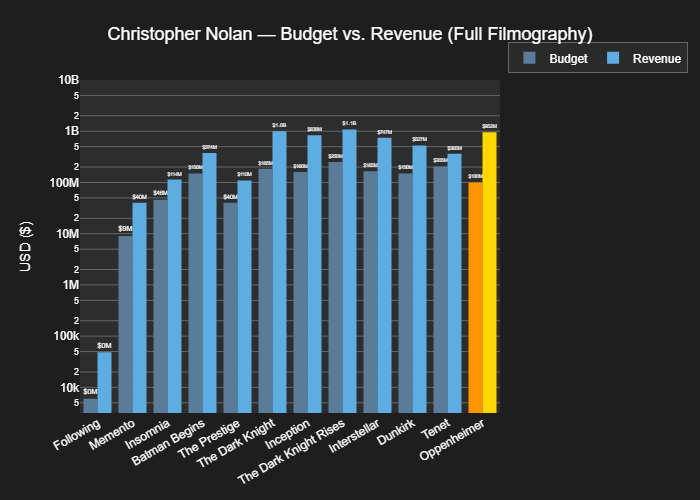

In [8]:
# --- Chart: Nolan's Budget vs Revenue over time ---
fig = go.Figure()

# Color Oppenheimer differently
bar_colors_budget = [
    COLORS["oppenheimer"] if t == "Oppenheimer" else COLORS["nolan"]
    for t in nolan["title"]
]
bar_colors_revenue = [
    "#FFD700" if t == "Oppenheimer" else COLORS["nolan_accent"]
    for t in nolan["title"]
]

fig.add_trace(go.Bar(
    x=nolan["title"], y=nolan["budget"],
    name="Budget", marker_color=bar_colors_budget,
    text=nolan["budget"].apply(fmt_millions), textposition="outside",
))
fig.add_trace(go.Bar(
    x=nolan["title"], y=nolan["revenue"],
    name="Revenue", marker_color=bar_colors_revenue,
    text=nolan["revenue"].apply(fmt_millions), textposition="outside",
))

fig.update_layout(
    title="Christopher Nolan — Budget vs. Revenue (Full Filmography)",
    height=500, barmode="group",
    yaxis_title="USD ($)",
    yaxis_type="log",
    yaxis_range=[3.5, 10],  # $3K to $10B range on log scale
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
    xaxis_tickangle=-30,
)
fig.show()

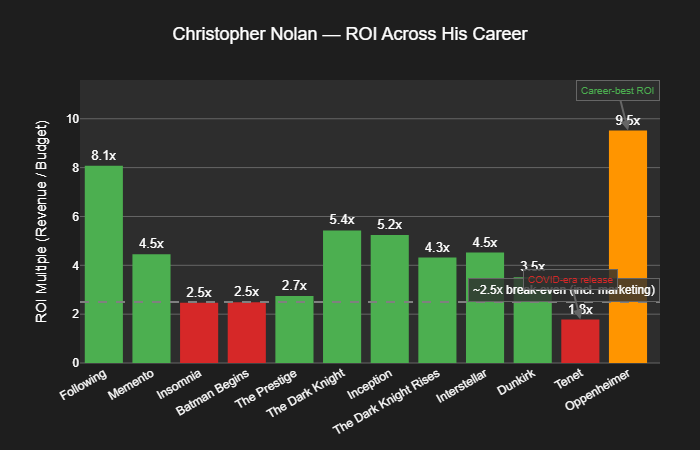

In [9]:
# --- Chart: Nolan ROI over time ---
fig = go.Figure()

roi_colors = [
    COLORS["oppenheimer"] if t == "Oppenheimer"
    else COLORS["loss"] if r < 2.5
    else COLORS["profit"]
    for t, r in zip(nolan["title"], nolan["roi"])
]

# Cap Following's 8x ROI for readability but it's fine actually
fig.add_trace(go.Bar(
    x=nolan["title"], y=nolan["roi"],
    marker_color=roi_colors,
    text=nolan["roi"].apply(lambda x: f"{x:.1f}x"),
    textposition="outside",
))

fig.add_hline(y=2.5, line_dash="dash", line_color="gray",
              annotation_text="~2.5x break-even (incl. marketing)")

# Annotate Tenet (COVID) and Oppenheimer (comeback)
fig.add_annotation(
    x="Tenet", y=nolan[nolan["title"]=="Tenet"]["roi"].values[0],
    text="COVID-era release", showarrow=True, arrowhead=2, ay=-40,
    font=dict(size=10, color=COLORS["loss"]),
)
fig.add_annotation(
    x="Oppenheimer", y=nolan[nolan["title"]=="Oppenheimer"]["roi"].values[0],
    text="Career-best ROI", showarrow=True, arrowhead=2, ay=-40,
    font=dict(size=10, color=COLORS["profit"]),
)

fig.update_layout(
    title="Christopher Nolan — ROI Across His Career",
    yaxis_title="ROI Multiple (Revenue / Budget)",
    height=450, showlegend=False,
    xaxis_tickangle=-30,
)
fig.show()

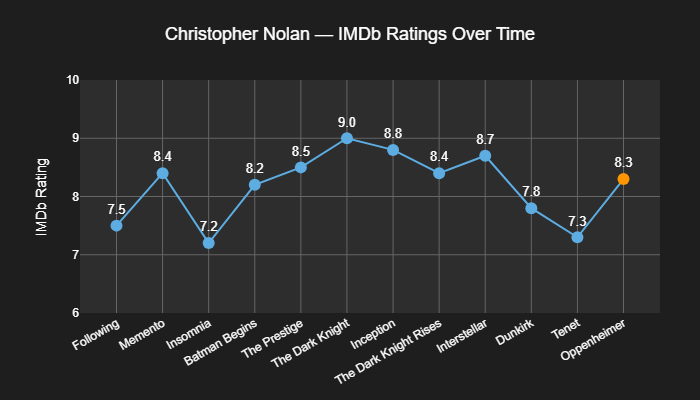

In [10]:
# --- Chart: Nolan's IMDb ratings over time ---
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=nolan["title"], y=nolan["imdb_rating"],
    mode="lines+markers+text",
    marker=dict(
        size=12,
        color=[
            COLORS["oppenheimer"] if t == "Oppenheimer" else COLORS["nolan_accent"]
            for t in nolan["title"]
        ],
    ),
    text=nolan["imdb_rating"].apply(lambda x: f"{x:.1f}"),
    textposition="top center",
    line=dict(color=COLORS["nolan_accent"], width=2),
    name="IMDb Rating",
))

fig.update_layout(
    title="Christopher Nolan — IMDb Ratings Over Time",
    yaxis_title="IMDb Rating",
    yaxis_range=[6, 10],
    height=400, showlegend=False,
    xaxis_tickangle=-30,
)
fig.show()

### Nolan's Career Arc — The Oppenheimer Comeback

Christopher Nolan's filmography reads like a masterclass in scaling ambition — and as a fellow Chris, I'm biased, but the man delivers.

- **The indie years** (1998–2002): *Following* ($6K budget, 8x ROI — technically his best investment ever) and *Memento* ($9M, 4.5x) established him as a visionary who could do more with less.
- **The blockbuster era** (2005–2012): The Dark Knight trilogy and *Inception* cemented his status as Hollywood's "smart blockbuster" director. The Batman films are peak Nolan for me — grounded, gritty, and elevated by what might be the greatest villain performance in cinema history: Heath Ledger's Joker (RIP). That Oscar was posthumous and entirely deserved. *Inception* was equally brilliant — a heist movie inside dreams inside dreams that somehow made complete (ish) sense. Every film delivered strong returns.
- **Prestige at scale** (2014–2017): *Interstellar* was ambitious and gorgeous — the kind of film that makes you feel small in the best way. *Dunkirk* is where you start to see Nolan's "challenge run" approach to filmmaking — he *insisted* on no CGI effects, which meant some shots look a bit empty (where are all the soldiers at Dunkirk?), but he kept his promise and the result is viscerally real. ROI began slipping as budgets inflated, but the films were unimpeachable. More on these two later — they're among my all-time favorite cinema experiences.
- **The Tenet gambit** (2020): In the lead-up to Tenet, Nolan did something quietly brilliant: he re-released his entire back catalogue in cinemas. It was a hype campaign, sure, but it was also a *gift* to anyone who'd missed these films on the big screen. I got to see *Interstellar* again and actually saw *Inception* for the first time in cinemas, both IMAX of course. Interstellar in IMAX was nothing short of revelatory — the sound design alone is revolutionary and did as much for my immersion as the visuals which in their own right feel like you got swallowed into the screen whole. No living room is ever going to compete wit hany of that. The feeling of the whoel cinema shaking during the landing (watering?) on the water planet and the visual of an actual craft they build going on that water is just peak movie-making. Those two are probably my favourite films I've ever seen in a cinema, and they use IMAX the way IMAX was meant to be used: not as a gimmick, but as the *entire point*. As for Tenet itself — I'd consider it a great example of Nolan in both the best and worst ways. Shooting a film where half the action runs *backwards in time* is an enormous technical achievement — the kind of thing only Nolan would even attempt. It's a "challenge run" movie: he set himself an absurd constraint and then solved it. But the result, while intellectually fascinating, doesn't translate well for anyone who isn't a devoted cinephile. It's more impressive to think about than to watch. Released during COVID (Nolan *insisted* on theatrical, naturally), it earned just 1.78x its $205M budget — his first wide-release financial miss. The fallout fractured his relationship with Warner Bros., leading to his very public move to Universal.
- **The Oppenheimer triumph** (2023): With a deliberately lean $100M budget, Oppenheimer earned **9.52x** — Nolan's best ROI since his micro-budget debut film 25 years earlier. It proved that Nolan didn't need $200M+ budgets to deliver. More importantly, it won him the Oscar.

> 🎥 **The lesson**: Oppenheimer's $100M budget was no accident — it was a *strategic overcorrection* after Tenet's bloat. By keeping costs disciplined, Nolan ensured that even a niche audience (three-hour R-rated historical drama fans) could deliver blockbuster-level returns. The Barbenheimer wave was a bonus. The economics would have worked regardless.
> 
> What I love about Nolan's career is the **self-imposed challenge runs**. Memento runs backwards. The Prestige hides the twist in plain sight. Dunkirk refuses CGI. Tenet inverts time. Interstellar simulates a black hole with actual physics. Each film sets a constraint that would sink a lesser director — and Nolan treats it as the point. Oppenheimer's constraint? Make a $100M film feel like a $250M one. Nailed it.

---

## 4. 📊 2023 Box Office Context — Barbenheimer Dominated Everything

So Barbenheimer crushed it — but how did 2023 *overall* treat big-budget films? Was it a strong year where everyone won, or did Barbie and Oppenheimer soak up the oxygen while the rest suffocated? (Spoiler: it's the second one. And honestly? Most of what suffocated *deserved* to suffocate.)

In [11]:
# Load 2023 big-budget movies
peers_2023 = execute_custom_query("""
    SELECT
        t.title,
        t.release_date,
        t.budget,
        t.revenue,
        t.vote_average AS tmdb_rating,
        ROUND(CAST(t.revenue AS DOUBLE) / t.budget, 2) AS roi
    FROM tmdb_movies t
    WHERE t.budget >= 100000000
      AND t.revenue > 0
      AND t.release_date BETWEEN '2023-01-01' AND '2023-12-31'
    ORDER BY roi DESC
""")

peers_2023["is_barbenheimer"] = peers_2023["title"].isin(["Barbie", "Oppenheimer"])
print(f"Found {len(peers_2023)} big-budget movies from 2023")
peers_2023[["title", "budget", "revenue", "roi", "tmdb_rating"]].head(15)

Found 29 big-budget movies from 2023


,title,budget,revenue,roi,tmdb_rating
0,The Super Mario Bros. Movie,100000000,1362000000,13.62,7.60
1,Barbie,145000000,1447138421,9.98,6.94
2,Oppenheimer,100000000,952000000,9.52,8.04
3,Spider-Man: Across the Spider-Verse,100000000,690897910,6.91,8.34
4,Wonka,125000000,634502312,5.08,7.05
5,John Wick: Chapter 4,100000000,440157245,4.40,7.72
6,Guardians of the Galaxy Vol. 3,250000000,845550000,3.38,7.93
7,The Hunger Games: The Ballad of Songbirds & Sn...,100000000,337371917,3.37,7.00
8,Meg 2: The Trench,129000000,384056482,2.98,6.40
9,Elemental,200000000,496444308,2.48,7.59


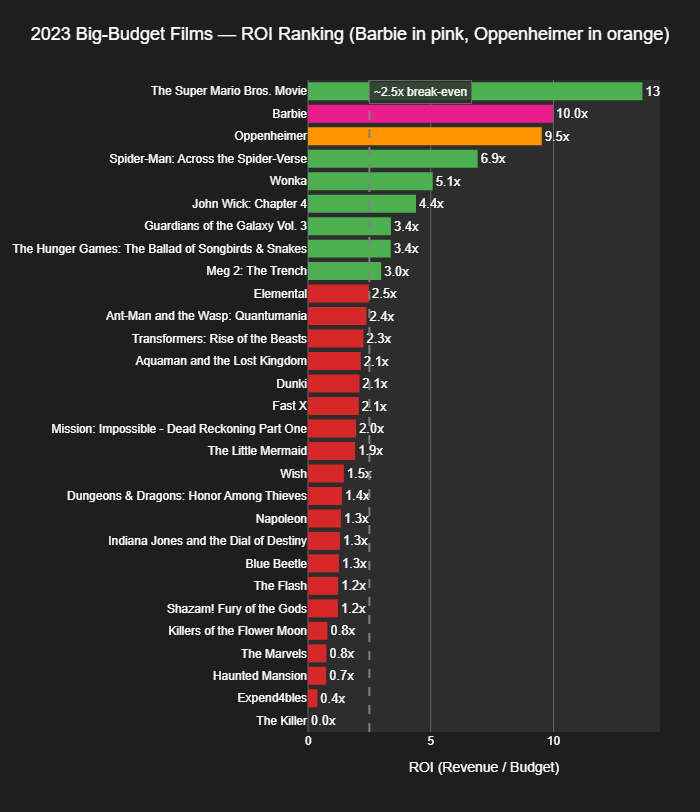

In [12]:
# ROI ranking for 2023 big-budget films
peers_sorted = peers_2023.sort_values("roi", ascending=True).copy()

# Assign colors
def get_bar_color(row):
    if row["title"] == "Barbie":
        return COLORS["barbie"]
    if row["title"] == "Oppenheimer":
        return COLORS["oppenheimer"]
    if row["roi"] >= 2.5:
        return COLORS["profit"]
    return COLORS["loss"]

peers_sorted["color"] = peers_sorted.apply(get_bar_color, axis=1)

fig = go.Figure(go.Bar(
    y=peers_sorted["title"],
    x=peers_sorted["roi"],
    orientation="h",
    marker_color=peers_sorted["color"],
    text=peers_sorted["roi"].apply(lambda x: f"{x:.1f}x"),
    textposition="outside",
))

fig.add_vline(x=2.5, line_dash="dash", line_color="gray",
              annotation_text="~2.5x break-even")

fig.update_layout(
    title="2023 Big-Budget Films — ROI Ranking (Barbie in pink, Oppenheimer in orange)",
    xaxis_title="ROI (Revenue / Budget)",
    height=max(500, len(peers_sorted) * 28),
    margin=dict(l=300),
)
fig.show()

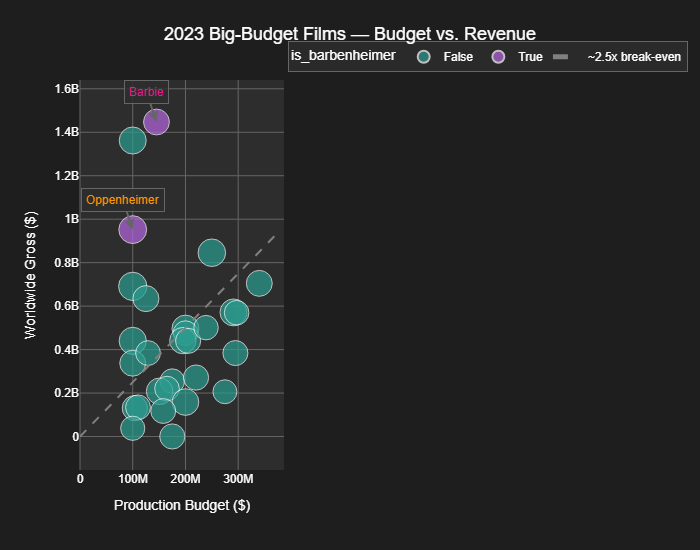

In [13]:
# Scatter: Budget vs Revenue for 2023
fig = px.scatter(
    peers_2023,
    x="budget", y="revenue",
    size="tmdb_rating", size_max=20,
    color="is_barbenheimer",
    color_discrete_map={True: COLORS["combined"], False: COLORS["comparison"]},
    hover_name="title",
    hover_data={"budget": ":$,.0f", "revenue": ":$,.0f", "roi": ":.2f", "is_barbenheimer": False},
    labels={"budget": "Production Budget ($)", "revenue": "Worldwide Gross ($)"},
    title="2023 Big-Budget Films — Budget vs. Revenue",
)

# Break-even line
max_budget = peers_2023["budget"].max() * 1.1
fig.add_trace(go.Scatter(
    x=[0, max_budget], y=[0, max_budget * 2.5],
    mode="lines", line=dict(dash="dash", color="gray"),
    name="~2.5x break-even", showlegend=True,
))

# Annotate Barbie and Oppenheimer
for title, color in [("Barbie", COLORS["barbie"]), ("Oppenheimer", COLORS["oppenheimer"])]:
    row = peers_2023[peers_2023["title"] == title].iloc[0]
    fig.add_annotation(
        x=row["budget"], y=row["revenue"],
        text=title, showarrow=True, arrowhead=2,
        font=dict(size=12, color=color),
    )

fig.update_layout(
    height=550, showlegend=True,
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
)
fig.show()

### 2023: The Year of Extremes

The 2023 box office landscape wasn't just polarized — it was *brutally* Darwinian:

- **The mega-winners**: *Super Mario Bros.* (13.6x — turns out people really do love Nintendo), *Barbie* (10.0x), and *Oppenheimer* (9.5x) delivered extraordinary returns.
- **The comfortable middle**: *Spider-Verse 2*, *Wonka*, and *John Wick 4* were solidly profitable. Nothing spectacular, nothing catastrophic.
- **The carnage**: Expensive franchise tentpoles like *The Flash* (1.2x — a $220M investment that needed resuscitation), *Indiana Jones 5* (1.3x — Harrison Ford's final swashbuckle limped to the finish), *The Marvels* (0.75x — one of Marvel's worst bombs), and *Wish* (1.5x — Disney Animation's 100th anniversary film, ironically forgettable) were financial disasters. Not to put too fine a point on it, but every single one of these was a **franchise sequel or spinoff**. The pattern is not subtle.

What's remarkable is that **neither Barbie nor Oppenheimer had franchise safety nets**. Barbie was a first-time adaptation of a plastic doll (not exactly a proven box office bet after the wreckage of *Battleship*, *Jem and the Holograms*, and other toy-to-film disasters). Oppenheimer was an original historical drama about a physicist's guilt. Both succeeded on the strength of their directors' visions, sharp marketing, and — crucially — the Barbenheimer cultural rocket fuel.

Meanwhile, established franchises with $200–300M budgets flopped. The message was loud and clear: **audiences in 2023 rewarded quality and originality over franchise autopilot.** Whatever my issues with Barbie as a film (and there are many — see above), at least it was *trying* something new. The same cannot be said for Indiana Jones discovering yet another ancient artifact or the Marvels doing... whatever the Marvels was doing.

---

## 5. 🤝 The Symbiosis Effect — Why Competition Became Collaboration

Here's the part that broke every studio executive's brain: two films opening on the same weekend is supposed to be a *war*. One wins, one loses. Market share is zero-sum. That's the gospel.

Barbenheimer rewrote the gospel.

### Why This Worked

Several factors aligned to turn competition into the most effective cross-promotional campaign either film could have asked for — and neither had to pay a cent for it:

1. **Completely non-overlapping demographics**: Barbie targeted younger women and families; Oppenheimer targeted older male cinephiles. There was almost zero direct competition for the same ticket on the same night. The audience Venn diagram was two circles barely touching.

2. **The double-feature dare**: The tonal absurdity of watching both in one day was *inherently funny*. "Are you doing the Barbenheimer double feature?" became social currency. People went to *two* movies when they might not have gone to *one*.

3. **Cross-pollination of hype**: Every meme comparing the two was free marketing for *both*. Oppenheimer thinkpieces inadvertently reminded people Barbie existed. Barbie fan art accidentally promoted nuclear physics. The rivalry was cooperative by design.

4. **The theatrical experience**: Both films were deliberately crafted for cinemas — Nolan shot in IMAX 65mm; Gerwig built a physical Barbie Land set. In a post-COVID world where "I'll wait for streaming" had become the default, Barbenheimer reminded people that going to the movies is *fun* — and worth leaving the couch for.

Let's visualize the domestic vs. international split to understand how differently these films traveled.

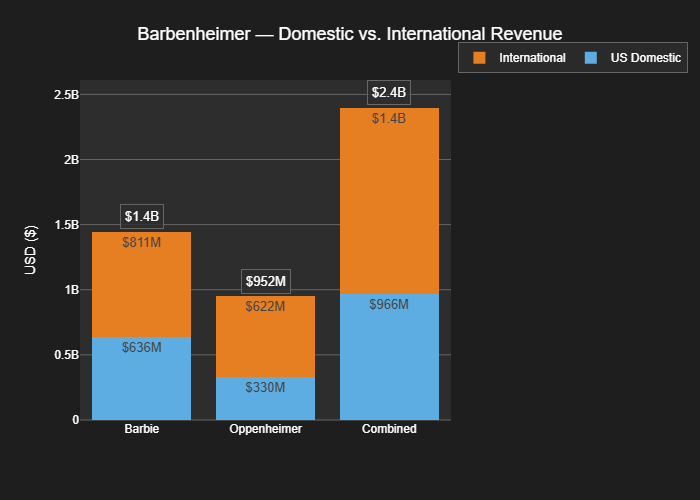

In [14]:
# Domestic vs International split — stacked bar
fig = go.Figure()

films = ["Barbie", "Oppenheimer", "Combined"]
domestic = [barbie["us_box_office"], oppenheimer["us_box_office"],
            barbie["us_box_office"] + oppenheimer["us_box_office"]]
international = [barbie["intl_box_office"], oppenheimer["intl_box_office"],
                 barbie["intl_box_office"] + oppenheimer["intl_box_office"]]

fig.add_trace(go.Bar(
    x=films, y=domestic, name="US Domestic",
    marker_color="#5DADE2",
    text=[fmt_millions(v) for v in domestic], textposition="inside",
))
fig.add_trace(go.Bar(
    x=films, y=international, name="International",
    marker_color="#E67E22",
    text=[fmt_millions(v) for v in international], textposition="inside",
))

# Annotate total on top
totals = [barbie["revenue"], oppenheimer["revenue"], combined_revenue]
for i, (film, total) in enumerate(zip(films, totals)):
    fig.add_annotation(
        x=film, y=total, text=fmt_millions(total),
        showarrow=False, yshift=15,
        font=dict(size=13, color="white"),
    )

fig.update_layout(
    title="Barbenheimer — Domestic vs. International Revenue",
    barmode="stack",
    yaxis_title="USD ($)", height=500,
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
)
fig.show()

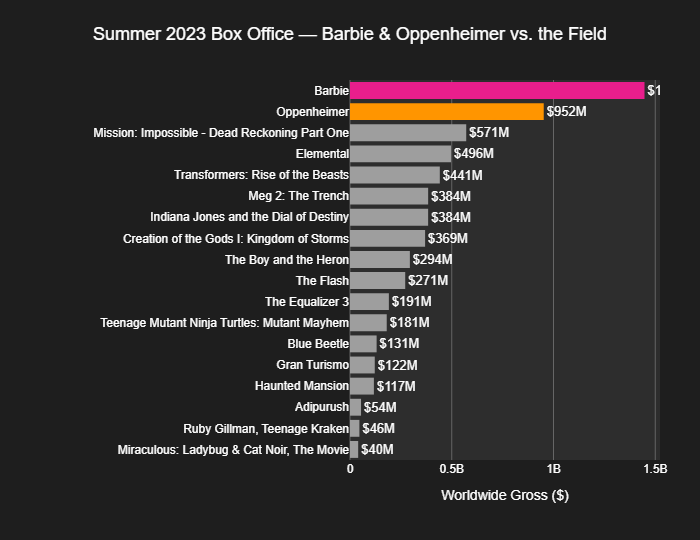

In [15]:
# Summer 2023 opening weekend context — how Barbenheimer compared to other summer releases
summer_2023 = execute_custom_query("""
    SELECT
        t.title,
        t.release_date,
        t.budget,
        t.revenue,
        t.vote_average AS tmdb_rating,
        ROUND(CAST(t.revenue AS DOUBLE) / t.budget, 2) AS roi
    FROM tmdb_movies t
    WHERE t.budget >= 50000000
      AND t.revenue > 0
      AND t.release_date BETWEEN '2023-06-01' AND '2023-08-31'
    ORDER BY t.revenue DESC
""")

summer_2023["is_barbenheimer"] = summer_2023["title"].isin(["Barbie", "Oppenheimer"])

# Summer blockbuster revenue comparison
fig = go.Figure()

summer_sorted = summer_2023.sort_values("revenue", ascending=True)

def get_summer_color(row):
    if row["title"] == "Barbie":
        return COLORS["barbie"]
    if row["title"] == "Oppenheimer":
        return COLORS["oppenheimer"]
    return COLORS["neutral"]

summer_sorted["color"] = summer_sorted.apply(get_summer_color, axis=1)

fig.add_trace(go.Bar(
    y=summer_sorted["title"],
    x=summer_sorted["revenue"],
    orientation="h",
    marker_color=summer_sorted["color"],
    text=summer_sorted["revenue"].apply(fmt_millions),
    textposition="outside",
))

fig.update_layout(
    title="Summer 2023 Box Office — Barbie & Oppenheimer vs. the Field",
    xaxis_title="Worldwide Gross ($)",
    height=max(400, len(summer_sorted) * 30),
    margin=dict(l=350),
)
fig.show()

### The Barbenheimer Hype Loop

What made this phenomenon self-sustaining was a **self-reinforcing hype cycle** that no studio marketing department could have engineered:

1. **Pre-release memes** — The absurd contrast spawned viral content *months* before release. Every Barbie trailer reminded people about Oppenheimer, and vice versa. The internet couldn't talk about one without mentioning the other.
2. **The double-feature dare** — "Are you doing the Barbenheimer double feature?" became the defining social question of July 2023. People went to *two* movies in one day when they might not have gone to *one*. Some theaters reported the highest single-day attendance since the pandemic.
3. **Cross-demographic pull** — Partners and friend groups with different tastes struck deals: "I'll do yours if you do mine." Boyfriends who'd never voluntarily watch a Barbie movie sat through it with a grin. Girlfriends who thought Oppenheimer would be boring came out raving. Everyone won.
4. **FOMO amplification** — Once opening-weekend numbers were massive, the narrative became "everyone is seeing both." This drove second and third weekend attendance from the "wait and see" crowd who now felt left out of the conversation.

The combined opening weekend for both films was approximately **$244M domestic** — the biggest non-holiday weekend of 2023, powered by two films that "competed" for the same screens but barely competed for the same *audience*.

And this is what I want more of. Not specifically another Barbenheimer — that lightning won't strike twice in the same way — but the *energy* it represented. People excited to go to the movies. People making a day of it. People treating the cinema as somewhere you *want* to be, not just somewhere you end up when there's nothing on Netflix. I sat through Inception and Interstellar in IMAX thanks to Nolan's pre-Tenet re-releases and those screenings reminded me why cinema exists: because some films are *built* for a room with a screen the size of a building and sound that vibrates your ribs. If Barbenheimer getting people back in seats means we occasionally have to sit through a Barbie-caliber script to keep the lights on — fine. I'll take that trade. Keep the cinemas alive so the Nolans of the world have somewhere to put their IMAX prints.

> 🎞️ **Compare this to the Furiosa case study**: Where Furiosa struggled because it was a franchise film *without* its franchise star, Barbie and Oppenheimer thrived because they were **originals with clear creative visions**. No sequel fatigue, no franchise baggage — just two auteur directors delivering something genuinely distinctive. The contrast couldn't be sharper.

---

## 6. 🎥 The Directors — Nolan's Mastery Meets Gerwig's Breakout

Both directors arrived at Barbenheimer on very different trajectories — and that contrast is itself a miniature of the phenomenon. One was a 25-year industry titan scaling *down* to prove he could still be efficient. The other was an indie darling scaling *up* to prove she could play in the tentpole arena. Both delivered.

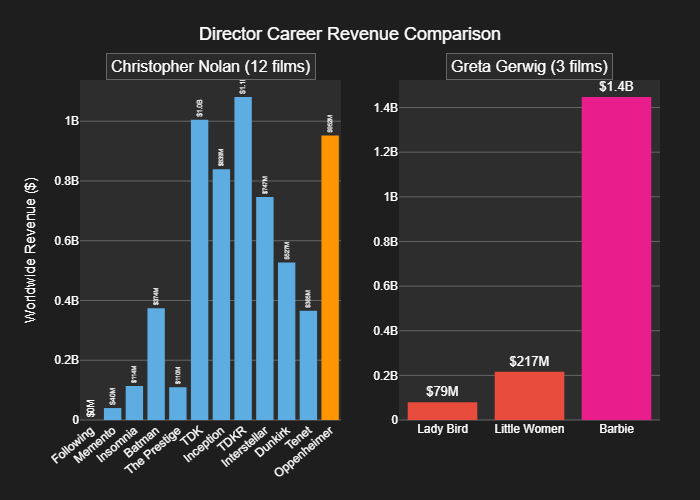

In [16]:
# Load Gerwig's filmography for comparison
gerwig = execute_custom_query("""
    SELECT
        t.title,
        t.release_date,
        t.budget,
        t.revenue,
        t.vote_average AS tmdb_rating,
        o.imdb_rating,
        o.rotten_tomatoes_rating AS rt_score,
        o.metascore,
        ROUND(CAST(t.revenue AS DOUBLE) / NULLIF(t.budget, 0), 2) AS roi
    FROM tmdb_movies t
    LEFT JOIN movies m ON t.tmdb_id = m.tmdb_id
    LEFT JOIN omdb_movies o ON m.imdb_id = o.imdb_id
    WHERE o.director LIKE '%Greta Gerwig%'
      AND t.budget > 0
      AND t.revenue > 0
    ORDER BY t.release_date
""")

gerwig["release_year"] = pd.to_datetime(gerwig["release_date"]).dt.year

# Side-by-side director career comparison
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Christopher Nolan (12 films)", "Greta Gerwig (3 films)"),
    shared_yaxes=False,
)

# Nolan
nolan_short = nolan["title"].apply(
    lambda x: x.replace("The Dark Knight Rises", "TDKR")
              .replace("The Dark Knight", "TDK")
              .replace("Batman Begins", "Batman")
)
fig.add_trace(go.Bar(
    x=nolan_short, y=nolan["revenue"],
    marker_color=[
        COLORS["oppenheimer"] if t == "Oppenheimer" else COLORS["nolan_accent"]
        for t in nolan["title"]
    ],
    text=nolan["revenue"].apply(fmt_millions),
    textposition="outside", textangle=-90,
    showlegend=False,
), row=1, col=1)

# Gerwig
fig.add_trace(go.Bar(
    x=gerwig["title"], y=gerwig["revenue"],
    marker_color=[
        COLORS["barbie"] if t == "Barbie" else COLORS["gerwig"]
        for t in gerwig["title"]
    ],
    text=gerwig["revenue"].apply(fmt_millions),
    textposition="outside",
    showlegend=False,
), row=1, col=2)

fig.update_layout(
    title="Director Career Revenue Comparison",
    height=500,
)
fig.update_yaxes(title_text="Worldwide Revenue ($)", row=1, col=1)
fig.update_xaxes(tickangle=-40, row=1, col=1)
fig.show()

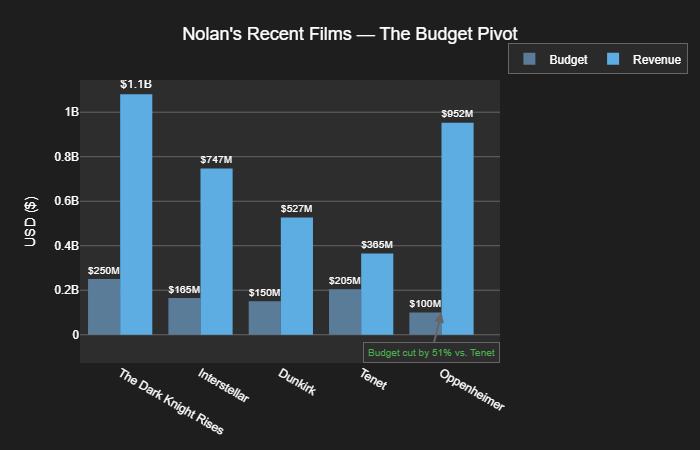

In [17]:
# Nolan's budget strategy — lean Oppenheimer vs. bloated Tenet
fig = go.Figure()

# Focus on Nolan's last 5 films to show the budget pivot
recent_nolan = nolan[nolan["release_year"] >= 2012].copy()

fig.add_trace(go.Bar(
    x=recent_nolan["title"], y=recent_nolan["budget"],
    name="Budget", marker_color=COLORS["nolan"],
    text=recent_nolan["budget"].apply(fmt_millions), textposition="outside",
))
fig.add_trace(go.Bar(
    x=recent_nolan["title"], y=recent_nolan["revenue"],
    name="Revenue", marker_color=COLORS["nolan_accent"],
    text=recent_nolan["revenue"].apply(fmt_millions), textposition="outside",
))

# Annotate the budget pivot
fig.add_annotation(
    x="Oppenheimer", y=100000000,
    text="Budget cut by 51%\nvs. Tenet",
    showarrow=True, arrowhead=2, ay=40,
    font=dict(size=10, color=COLORS["profit"]),
)

fig.update_layout(
    title="Nolan's Recent Films — The Budget Pivot",
    barmode="group",
    yaxis_title="USD ($)", height=450,
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
)
fig.show()

### Director Trajectories — The Mirror Image

**Christopher Nolan** arrived at Barbenheimer as the establishment master with something to prove:
- 25-year career, 11 previous films, cumulative gross exceeding $5B worldwide
- *Halved* his budget from Tenet ($205M) to Oppenheimer ($100M) — a deliberate strategic pivot after COVID losses and a failed experiment with blockbuster bloat
- Publicly split from Warner Bros. over HBO Max simultaneous releases — "the worst streaming service"
- Oppenheimer was his first Best Director Oscar, his first Best Picture win, and his most *efficient* blockbuster. The redemption arc practically writes itself.
- The man directs movies like he's speedrunning with self-imposed restrictions. No CGI in Dunkirk. Reverse chronology in Memento. Inverted time in Tenet. $100M ceiling for Oppenheimer. He's the only director in Hollywood who treats filmmaking like a challenge run — and at this point, the challenge runs are producing better results than the unlimited budgets ever did.

**Greta Gerwig** arrived as the underdog — just her third film as director, and her first over $50M:
- *Lady Bird* (2017): $10M budget → $79M gross, 99% RT, multiple Oscar nominations. The indie breakthrough.
- *Little Women* (2019): $40M budget → $217M gross, 95% RT, Oscar win for Best Costume Design. The studio test run.
- *Barbie* (2023): $145M budget → $1.45B gross — a **14x scale-up** in budget that somehow delivered her *best* ROI. The blockbuster coronation.
- Each film was bigger and bolder than the last: a perfect escalation from indie darling to the woman who made the highest-grossing movie of the year. Whatever my thoughts on Barbie's messaging, the *scale* of what Gerwig pulled off commercially is undeniable.

> 💡 **The contrast in their paths is itself a miniature of Barbenheimer**: Nolan — the master scaling *down* to find efficiency; Gerwig — the indie voice scaling *up* and proving she belonged. One took a budget cut. The other took a leap of faith. Both stuck the landing financially, even if only one of them stuck the landing narratively (in this author's humble opinion).

## Conclusions

### What Made Barbenheimer Lightning in a Bottle?

1. **The contrast *was* the marketing**: Two films so diametrically opposed that the juxtaposition became the story. Every meme, every "which are you seeing first?" post, every pink-and-black outfit on social media was free advertising for both films. You couldn't scroll past one without seeing the other.

2. **Non-overlapping audiences with cross-pollination**: Barbie's core demographic (women 18–40) and Oppenheimer's (men 25–55) barely overlapped — but couples and friend groups used each other as an excuse to see both. "I'll go to yours if you go to mine" was the defining transaction of July 2023.

3. **Auteur vision over franchise formula**: Neither film was a sequel, prequel, spinoff, or franchise entry. Both were driven by a singular directorial vision — Nolan's meticulous historical reconstruction and Gerwig's subversive feminist comedy. In a year where franchise fatigue torpedoed *The Flash*, *Indiana Jones 5*, and *The Marvels*, **originality was the winning strategy**. Even if one of those original visions was more coherent than the other.

4. **Budget discipline that paid dividends**: Oppenheimer's $100M was lean for a Nolan film (his previous four ranged $150–250M). Barbie's $145M was significant but not bloated. Neither film needed $1B+ to be profitable — anything above $400M would have been a win. Both cleared that threshold by multiples.

5. **The theatrical event — cinema as it should be**: Both directors made films that *demanded* the big screen. Nolan shot in IMAX 65mm; Gerwig built a physical Barbie Land set. In a post-COVID, "I'll wait for streaming" era, Barbenheimer reminded audiences that **going to the movies is a shared experience**. This is what cinema is *for* — not just consuming content on a slightly bigger screen, but being pinned to your seat by something that fills your entire field of vision and rattles your ribcage. Having experienced Interstellar in IMAX, I can tell you: there is no streaming substitute for that. Barbenheimer proved that theaters can still generate massive returns when given a reason to exist.

### Nolan's Arc — The Comeback King

Oppenheimer was more than a hit — it was a **vindication**. After Tenet's COVID-muted performance and his acrimonious departure from Warner Bros., Nolan delivered his most commercially efficient film at Universal. The 9.5x ROI on $100M proved his brand doesn't need $200M+ to work. His filmography now spans 12 films with a cumulative gross exceeding $5 billion — and Oppenheimer finally earned him the Best Director and Best Picture Oscars he'd been chasing for two decades. Not a bad year.

As a fellow Chris, I can't help but root for the man. From reinventing Batman to bending reality in Inception to shooting a war film with zero CGI just because he said he would — Nolan's career is a masterclass in making yourself indispensable to Hollywood by doing things nobody else would attempt. Oppenheimer was the exclamation point on an already legendary run.

### The Bigger Lesson

Hollywood's conventional wisdom says same-day releases cannibalize each other and that franchise IP is the only safe bet for big budgets. Barbenheimer shattered both assumptions in a single weekend:

- **Competition can be collaboration** when the products are different enough.
- **Original properties** with strong creative visions can outperform established franchises.
- **Budget discipline** matters more than raw spending — both films kept budgets well below $200M and reaped massive returns.
- **Cultural moments can't be manufactured** — but they can be enabled by giving talented filmmakers the freedom to make something distinctive.
- **Cinema isn't dead** — it just needs directors who make films worth leaving the house for. Nolan has always understood this. Barbenheimer proved the audience agrees.

### Final Thoughts — Where I Actually Land

Here's the thing: Barbenheimer as a *phenomenon* was perfect. Two films, one weekend, maximum cultural chaos. Commercially? Both delivered. But if we're being honest about which film holds up as a piece of filmmaking — it's not close.

Oppenheimer is a film I'll revisit for years. The structure, the performances, the weight of what it's trying to say about human ambition and its consequences. It's Nolan doing what Nolan does best: taking something that shouldn't work as a movie (three hours of physics and government hearings) and making it unmissable. It's the kind of film that makes me grateful cinema exists — the kind that justifies every overpriced IMAX ticket and every commute to a theater when the couch is right there.

Barbie made $1.4 billion. I can acknowledge the commercial achievement, Margot Robbie's commitment, and the sheer audacity of a self-aware Mattel movie. But don't ask me to pretend the script earned that box office. Ryan Gosling walking away with the film's only Oscar nomination — for playing the character the movie mocks — tells you everything about where the real talent was on screen.

Still — if Barbie filling seats keeps the cinemas open for the next Inception, the next Interstellar, the next Oppenheimer? Then play on, Barbie. Play on.

> 🎥 *Barbenheimer proved Hollywood can still create lightning in a bottle. One of those films was a cultural moment. The other was a great movie. And if you've read this far, you know which one I think was which.*